<h2> Visualizations terminal results</h2>

In [27]:
import math
import json
import pandas as pd
import numpy as np
import ast
from matplotlib import pyplot as plt
import scipy.stats
import seaborn as sns

In [28]:
def read_scores(file):
    scores = []
    for line in file:
        if line[0] == "{":
            scores.append(json.loads(json.dumps(ast.literal_eval(line.strip()))))
    return scores

In [29]:
def create_CER_dataset(scores):
    epochs = []
    valid_loss = []
    valid_CharacTER = []
    
    for score in scores:
        epochs.append(score["epoch"])
        valid_loss.append(score["valid_loss"])
        valid_CharacTER.append(score["valid_CharacTER"])
        
    return pd.DataFrame({'epoch': epochs, 'valid_loss': valid_loss, 'valid_CharacTER': valid_CharacTER})    

In [30]:
def create_LEV_dataset(scores):
    epochs = []
    valid_loss = []
    valid_mean_leven = []
    valid_std_leven = []
    
    for score in scores:
        epochs.append(score["epoch"])
        valid_loss.append(score["valid_loss"])
        valid_mean_leven.append(score["valid_mean_levenshtein"]*100)
        valid_std_leven.append(score["valid_std_levenshtein"]*100)
        
    return pd.DataFrame({'epoch': epochs, 'valid_loss': valid_loss, 
                         'valid_mean_levenshtein': valid_mean_leven, 'valid_std_levenshtein': valid_std_leven})

<h3>Training 2: Transcriptions and Augmentations</h3>

In [31]:
file = open("results_model_v1/terminal/tr_02_ignore.txt", "r")
scores = read_scores(file)
dataset_ignore = create_CER_dataset(scores)

file = open("results_model_v1/terminal/tr_02_substitution.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_subst = create_CER_dataset(scores)

file = open("results_model_v1/terminal/tr_02_reduced.txt", "r")
scores = read_scores(file)
dataset_reduce = create_CER_dataset(scores)

Best evaluation ignore strategy: Epoch 16, value 3.185915315072006
Best evaluation substitution strategy: Epoch 138, value 3.804489331387998
Best evaluation reduce strategy: Epoch 49, value 2.586785526370685


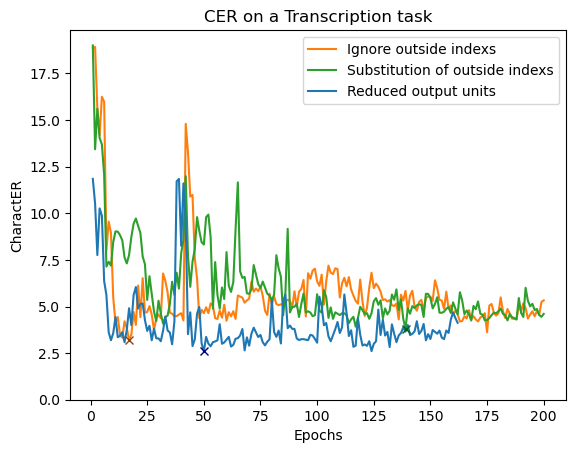

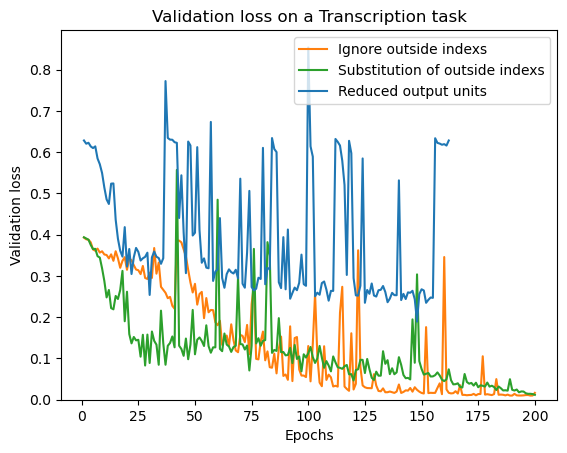

In [32]:
# Visualize training CharacTER
plt.plot(dataset_ignore["epoch"], dataset_ignore["valid_CharacTER"], label='Ignore outside indexs', color="tab:orange")
plt.plot(dataset_subst["epoch"], dataset_subst["valid_CharacTER"], label='Substitution of outside indexs', color="tab:green")
plt.plot(dataset_reduce["epoch"], dataset_reduce["valid_CharacTER"], label='Reduced output units', color="tab:blue")

minCER = np.argmin(dataset_ignore["valid_CharacTER"])
plt.plot(dataset_ignore["epoch"][minCER], dataset_ignore["valid_CharacTER"][minCER], marker='x', color="saddlebrown")
print("Best evaluation ignore strategy: Epoch " + str(minCER) + ", value " + str(dataset_ignore["valid_CharacTER"][minCER]))

minCER = np.argmin(dataset_subst["valid_CharacTER"])
plt.plot(dataset_subst["epoch"][minCER], dataset_subst["valid_CharacTER"][minCER], marker='x', color="darkgreen")
print("Best evaluation substitution strategy: Epoch " + str(minCER) + ", value " + str(dataset_subst["valid_CharacTER"][minCER]))

minCER = np.argmin(dataset_reduce["valid_CharacTER"])
plt.plot(dataset_reduce["epoch"][minCER], dataset_reduce["valid_CharacTER"][minCER], marker='x', color="navy")
print("Best evaluation reduce strategy: Epoch " + str(minCER) + ", value " + str(dataset_reduce["valid_CharacTER"][minCER]))

plt.xlabel('Epochs')
plt.ylabel('CharactER')
plt.legend()
plt.title("CER on a Transcription task")

plt.ylim(0)

plt.savefig('plots/terminal/tr_02_cer.png', bbox_inches='tight')
plt.show()


# Visualize training Loss
plt.plot(dataset_ignore["epoch"], dataset_ignore["valid_loss"], label='Ignore outside indexs', color="tab:orange")
plt.plot(dataset_subst["epoch"], dataset_subst["valid_loss"], label='Substitution of outside indexs', color="tab:green")
plt.plot(dataset_reduce["epoch"], dataset_reduce["valid_loss"], label='Reduced output units', color="tab:blue")

plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend()
plt.title("Validation loss on a Transcription task")

plt.ylim(0)

plt.savefig('plots/terminal/tr_02_cer_loss.png', bbox_inches='tight')
plt.show()

Best evaluation ignore strategy: Epoch 16, value 3.185915315072006
Best evaluation substitution strategy: Epoch 138, value 3.804489331387998
Best evaluation reduce strategy: Epoch 49, value 2.586785526370685


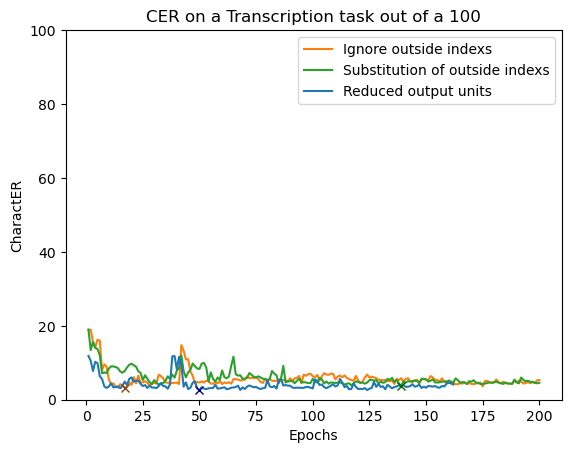

In [33]:
# Visualize training CharacTER
plt.plot(dataset_ignore["epoch"], dataset_ignore["valid_CharacTER"], label='Ignore outside indexs', color="tab:orange")
plt.plot(dataset_subst["epoch"], dataset_subst["valid_CharacTER"], label='Substitution of outside indexs', color="tab:green")
plt.plot(dataset_reduce["epoch"], dataset_reduce["valid_CharacTER"], label='Reduced output units', color="tab:blue")

minCER = np.argmin(dataset_ignore["valid_CharacTER"])
plt.plot(dataset_ignore["epoch"][minCER], dataset_ignore["valid_CharacTER"][minCER], marker='x', color="saddlebrown")
print("Best evaluation ignore strategy: Epoch " + str(minCER) + ", value " + str(dataset_ignore["valid_CharacTER"][minCER]))

minCER = np.argmin(dataset_subst["valid_CharacTER"])
plt.plot(dataset_subst["epoch"][minCER], dataset_subst["valid_CharacTER"][minCER], marker='x', color="darkgreen")
print("Best evaluation substitution strategy: Epoch " + str(minCER) + ", value " + str(dataset_subst["valid_CharacTER"][minCER]))

minCER = np.argmin(dataset_reduce["valid_CharacTER"])
plt.plot(dataset_reduce["epoch"][minCER], dataset_reduce["valid_CharacTER"][minCER], marker='x', color="navy")
print("Best evaluation reduce strategy: Epoch " + str(minCER) + ", value " + str(dataset_reduce["valid_CharacTER"][minCER]))

plt.ylim(0, 100)

plt.xlabel('Epochs')
plt.ylabel('CharactER')
plt.legend()
plt.title("CER on a Transcription task out of a 100")

plt.savefig('plots/terminal/tr_02_cer_100.png', bbox_inches='tight')
plt.show()

<br >

<h3>Training 3: Transcriptions and Augmentations</h3>

In [34]:
file = open("results_model_v1/terminal/tr_02_lev00.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_lev0 = create_LEV_dataset(scores)

file = open("results_model_v1/terminal/tr_02_lev01.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_lev1 = create_LEV_dataset(scores)

file = open("results_model_v1/terminal/tr_02_lev02.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_lev2 = create_LEV_dataset(scores)

file = open("results_model_v1/terminal/tr_02_lev03.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_lev3 = create_LEV_dataset(scores)

file = open("results_model_v1/terminal/tr_02_lev04.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_lev4 = create_LEV_dataset(scores)

file = open("results_model_v1/terminal/tr_02_lev05.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_lev5 = create_LEV_dataset(scores)

file = open("results_model_v1/terminal/tr_02_lev06.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_lev6 = create_LEV_dataset(scores)

file = open("results_model_v1/terminal/tr_02_lev07.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_lev7 = create_LEV_dataset(scores)

file = open("results_model_v1/terminal/tr_02_lev08.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_lev8 = create_LEV_dataset(scores)

file = open("results_model_v1/terminal/tr_02_lev09.txt", "r", encoding="utf8")
scores = read_scores(file)
dataset_lev9 = create_LEV_dataset(scores)

<br />

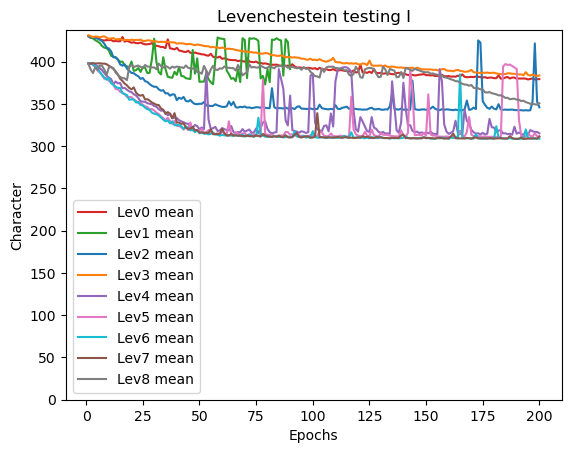

In [35]:
# Visualize training CharacTER + Levenchestein
plt.plot(dataset_lev0["epoch"], dataset_lev0["valid_mean_levenshtein"], label='Lev0 mean', color="tab:red")
plt.plot(dataset_lev1["epoch"], dataset_lev1["valid_mean_levenshtein"], label='Lev1 mean', color="tab:green")
plt.plot(dataset_lev2["epoch"], dataset_lev2["valid_mean_levenshtein"], label='Lev2 mean', color="tab:blue")
plt.plot(dataset_lev3["epoch"], dataset_lev3["valid_mean_levenshtein"], label='Lev3 mean', color="tab:orange")
plt.plot(dataset_lev4["epoch"], dataset_lev4["valid_mean_levenshtein"], label='Lev4 mean', color="tab:purple")
plt.plot(dataset_lev5["epoch"], dataset_lev5["valid_mean_levenshtein"], label='Lev5 mean', color="tab:pink")
plt.plot(dataset_lev6["epoch"], dataset_lev6["valid_mean_levenshtein"], label='Lev6 mean', color="tab:cyan")
plt.plot(dataset_lev7["epoch"], dataset_lev7["valid_mean_levenshtein"], label='Lev7 mean', color="tab:brown")
plt.plot(dataset_lev8["epoch"], dataset_lev8["valid_mean_levenshtein"], label='Lev8 mean', color="tab:gray")

plt.xlabel('Epochs')
plt.ylabel('Character')
plt.legend()
plt.title("Levenchestein testing I")

plt.ylim(0)

plt.savefig('plots/terminal/tr_02_lev_1.png', bbox_inches='tight')
plt.show()

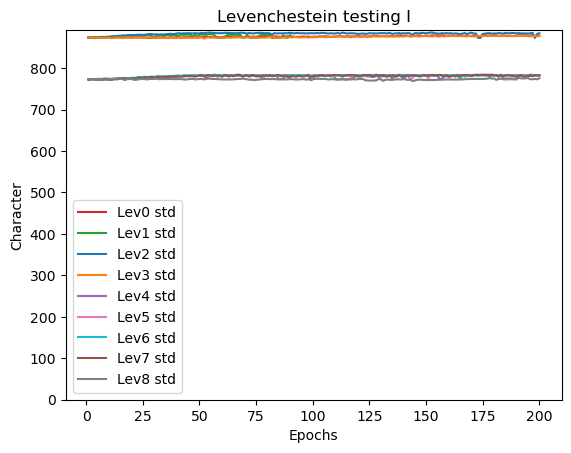

In [36]:
# Visualize training CharacTER + Levenchestein
plt.plot(dataset_lev0["epoch"], dataset_lev0["valid_std_levenshtein"], label='Lev0 std', color="tab:red")
plt.plot(dataset_lev1["epoch"], dataset_lev1["valid_std_levenshtein"], label='Lev1 std', color="tab:green")
plt.plot(dataset_lev2["epoch"], dataset_lev2["valid_std_levenshtein"], label='Lev2 std', color="tab:blue")
plt.plot(dataset_lev3["epoch"], dataset_lev3["valid_std_levenshtein"], label='Lev3 std', color="tab:orange")
plt.plot(dataset_lev4["epoch"], dataset_lev4["valid_std_levenshtein"], label='Lev4 std', color="tab:purple")
plt.plot(dataset_lev5["epoch"], dataset_lev5["valid_std_levenshtein"], label='Lev5 std', color="tab:pink")
plt.plot(dataset_lev6["epoch"], dataset_lev6["valid_std_levenshtein"], label='Lev6 std', color="tab:cyan")
plt.plot(dataset_lev7["epoch"], dataset_lev7["valid_std_levenshtein"], label='Lev7 std', color="tab:brown")
plt.plot(dataset_lev8["epoch"], dataset_lev8["valid_std_levenshtein"], label='Lev8 std', color="tab:gray")

plt.xlabel('Epochs')
plt.ylabel('Character')
plt.legend()
plt.title("Levenchestein testing I")

plt.ylim(0)

plt.savefig('plots/terminal/tr_02_lev_mean_1.png', bbox_inches='tight')
plt.show()

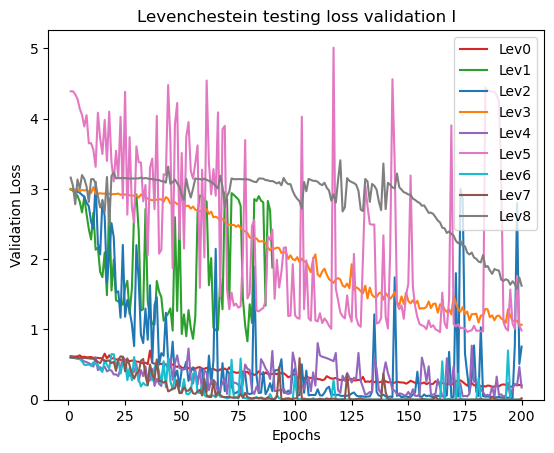

In [37]:
# Visualize training CharacTER + Levenchestein
plt.plot(dataset_lev0["epoch"], dataset_lev0["valid_loss"], label='Lev0', color="tab:red")
plt.plot(dataset_lev1["epoch"], dataset_lev1["valid_loss"], label='Lev1', color="tab:green")
plt.plot(dataset_lev2["epoch"], dataset_lev2["valid_loss"], label='Lev2', color="tab:blue")
plt.plot(dataset_lev3["epoch"], dataset_lev3["valid_loss"], label='Lev3', color="tab:orange")
plt.plot(dataset_lev4["epoch"], dataset_lev4["valid_loss"], label='Lev4', color="tab:purple")
plt.plot(dataset_lev5["epoch"], dataset_lev5["valid_loss"], label='Lev5', color="tab:pink")
plt.plot(dataset_lev6["epoch"], dataset_lev6["valid_loss"], label='Lev6', color="tab:cyan")
plt.plot(dataset_lev7["epoch"], dataset_lev7["valid_loss"], label='Lev7', color="tab:brown")
plt.plot(dataset_lev8["epoch"], dataset_lev8["valid_loss"], label='Lev8', color="tab:gray")

plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.title("Levenchestein testing loss validation I")

plt.ylim(0)

plt.savefig('plots/terminal/tr02_lev_loss_1.png', bbox_inches='tight')
plt.show()

<br >
<br >

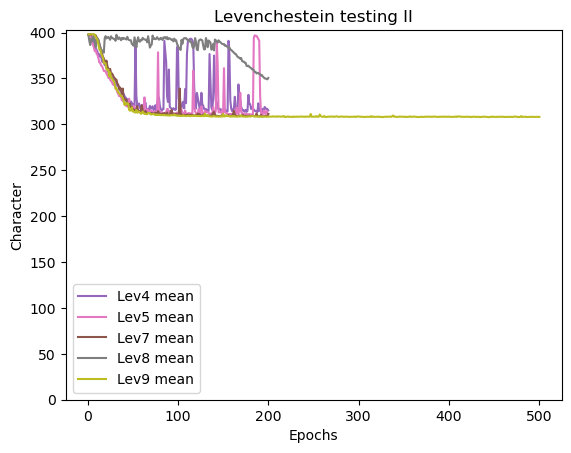

In [38]:
# Visualize training CharacTER + Levenchestein
plt.plot(dataset_lev4["epoch"], dataset_lev4["valid_mean_levenshtein"], label='Lev4 mean', color="tab:purple")
plt.plot(dataset_lev5["epoch"], dataset_lev5["valid_mean_levenshtein"], label='Lev5 mean', color="tab:pink")
plt.plot(dataset_lev7["epoch"], dataset_lev7["valid_mean_levenshtein"], label='Lev7 mean', color="tab:brown")
plt.plot(dataset_lev8["epoch"], dataset_lev8["valid_mean_levenshtein"], label='Lev8 mean', color="tab:gray")
plt.plot(dataset_lev9["epoch"], dataset_lev9["valid_mean_levenshtein"], label='Lev9 mean', color="tab:olive")

plt.xlabel('Epochs')
plt.ylabel('Character')
plt.legend()
plt.title("Levenchestein testing II")

plt.ylim(0)

plt.savefig('plots/terminal/tr_02_lev_2.png', bbox_inches='tight')
plt.show()

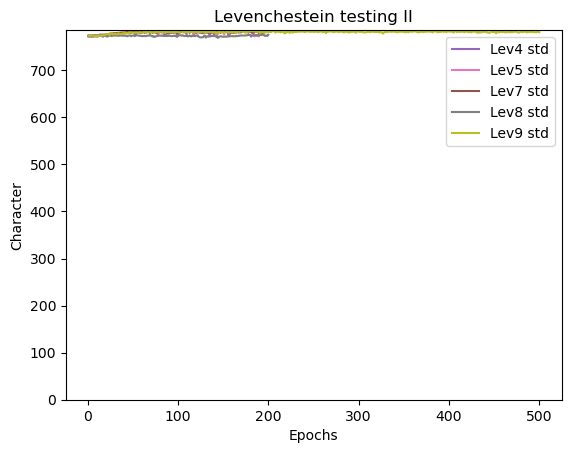

In [39]:
# Visualize training CharacTER + Levenchestein
plt.plot(dataset_lev4["epoch"], dataset_lev4["valid_std_levenshtein"], label='Lev4 std', color="tab:purple")
plt.plot(dataset_lev5["epoch"], dataset_lev5["valid_std_levenshtein"], label='Lev5 std', color="tab:pink")
plt.plot(dataset_lev7["epoch"], dataset_lev7["valid_std_levenshtein"], label='Lev7 std', color="tab:brown")
plt.plot(dataset_lev8["epoch"], dataset_lev8["valid_std_levenshtein"], label='Lev8 std', color="tab:gray")
plt.plot(dataset_lev9["epoch"], dataset_lev9["valid_std_levenshtein"], label='Lev9 std', color="tab:olive")

plt.xlabel('Epochs')
plt.ylabel('Character')
plt.legend()
plt.title("Levenchestein testing II")

plt.ylim(0)

plt.savefig('plots/terminal/tr_02_lev_mean_2.png', bbox_inches='tight')
plt.show()

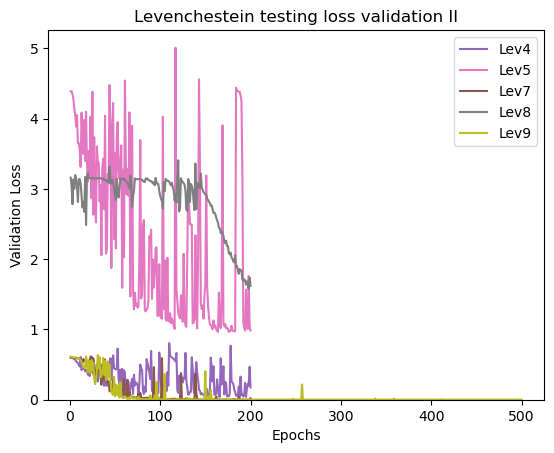

In [40]:
# Visualize training CharacTER + Levenchestein
plt.plot(dataset_lev4["epoch"], dataset_lev4["valid_loss"], label='Lev4', color="tab:purple")
plt.plot(dataset_lev5["epoch"], dataset_lev5["valid_loss"], label='Lev5', color="tab:pink")
plt.plot(dataset_lev7["epoch"], dataset_lev7["valid_loss"], label='Lev7', color="tab:brown")
plt.plot(dataset_lev8["epoch"], dataset_lev8["valid_loss"], label='Lev8', color="tab:gray")
plt.plot(dataset_lev9["epoch"], dataset_lev9["valid_loss"], label='Lev9', color="tab:olive")

plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.title("Levenchestein testing loss validation II")

plt.ylim(0)

plt.savefig('plots/terminal/tr02_lev_loss_2.png', bbox_inches='tight')
plt.show()

<br >